- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 11-1 잠재 공간에서 이미지를 만드는 방법 - 변분 오토인코더

본 노트북은 11-1절 본문 예제 [코드 11-1]~[코드 11-7]을 모아 위에서 아래로
실행해 본다. 7장 오토인코더에서 출발해, 잠재 공간을 확률 분포로 학습하는
변분 오토인코더(VAE)를 만들고 Fashion-MNIST 이미지를 복원·생성·보간한다.

**이 장의 코드 컨벤션 알림** - 11장은 생성 모델을 다루므로 GAN/VAE 도메인
표기를 사용한다. VAE의 잠재 분포 파라미터는 `mu`, `log_var`, 잠재 차원은
`LATENT_DIM`, 재구성 결과는 `recon`을 사용한다.

다루는 내용
- [코드 11-1] Fashion-MNIST 데이터셋 준비
- [코드 11-2]~[코드 11-3] FashionVAE 클래스 (인코더·재매개변수화·디코더)
- [코드 11-4] 복원 손실(BCE) + KL 발산을 합친 VAE 손실 함수
- [코드 11-5] VAE 학습 함수
- 본문 비공개 항목: 검증 함수, 전체 학습 루프, 학습 곡선 시각화
- [코드 11-6] 표준 정규 분포로 새 이미지 생성
- [코드 11-7] 잠재 공간 보간


이번 절은 본문의 모델 14의 구현을 포함한다. 모델 14의 제시문은 다음과 같다.

> **모델 14. 의류 이미지 생성 모델**
>
> Fashion-MNIST 데이터셋은 10종류의 의류가 포함된 흑백 이미지 데이터셋이다. 이 데이터셋을 학습해 임의의 의류 이미지를 생성해 보자.

## [코드 11-1] Fashion-MNIST 데이터셋 준비

Fashion-MNIST는 28x28 흑백 이미지 10종류의 의류로 구성된 데이터셋이다.[^fmnist]
VAE 디코더 출력에 시그모이드를 사용하므로 입력 이미지도 0~1 범위로 정규화해
맞춰 준다. 합성곱 신경망을 사용할 예정이므로 평탄화 변환은 추가하지 않는다.

본문은 `root='./data'`로 표기하지만, 노트북은 컨벤션 §13.9에 따라 자동
다운로드 데이터를 `root='../../download'`로 통일한다.

[^fmnist]: https://github.com/zalandoresearch/fashion-mnist — MIT License.


In [2]:
# 참고 -  Fashion-MNIST 데이터셋 준비

from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms

data_root = '../../download'

# 데이터 변환 객체: 픽셀 값을 0~1 범위로 정규화
transform = transforms.Compose([transforms.ToTensor()])

# Fashion-MNIST 데이터셋 생성
train_set = FashionMNIST(root=data_root, train=True, download=True, transform=transform)
valid_set = FashionMNIST(root=data_root, train=False, download=True, transform=transform)

# 데이터로더 생성(배치 크기 128)
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set):,}')
print(f'검증 샘플 수: {len(valid_set):,}')


훈련 샘플 수: 60,000
검증 샘플 수: 10,000


## [코드 11-2]~[코드 11-3] FashionVAE 클래스

인코더는 2개의 `nn.Conv2d` 합성곱 블록으로 (1, 28, 28) -> (64, 7, 7)까지
축소한 뒤, 두 개의 선형 계층(`fc_mu`, `fc_log_var`)으로 잠재 분포의 중심과
퍼짐을 동시에 학습한다. 디코더는 (B, LATENT_DIM) 잠재 벡터를 다시
(B, 64, 7, 7) 특징 지도로 재구성한 뒤 `nn.ConvTranspose2d`로 (1, 28, 28)까지
복원한다. 출력 활성화는 시그모이드다.

`reparameterize()`는 재매개변수화 트릭으로 잠재 분포에서 잠재 벡터 `z`를
선택한다. 학습 중에는 `mu + eps * std`로 샘플링하고, 추론 중에는 `mu`를
그대로 사용한다.


In [3]:
########################################################################################
# 코드 11-1, 11-2 - FashionVAE 클래스
########################################################################################
import torch
import torch.nn as nn

class FashionVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        # 인코더: 이미지 -> 특징 지도 (mu, log_var 계산은 별도 계층에서 수행)
        # (B, 1, 28, 28) -> (B, 32, 14, 14) -> (B, 64, 7, 7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flatten_size = 64 * 7 * 7              # 3136
        # 잠재 분포의 중심과 퍼짐을 계산하는 선형 계층
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_log_var = nn.Linear(self.flatten_size, latent_dim)
        # 잠재 벡터를 역합성곱 입력 형태로 변환
        self.fc_latent_to_feature = nn.Linear(latent_dim, self.flatten_size)
        # 디코더: 잠재 벡터를 이미지로 복원
        # (B, 64, 7, 7) -> (B, 32, 14, 14) -> (B, 1, 28, 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=2, padding=1, output_padding=1,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, kernel_size=3, stride=2, padding=1, output_padding=1,
            ),
            nn.Sigmoid(),       # 출력 범위 0~1 (입력 이미지 픽셀값과 동일)
        )

    # 합성곱 계층으로 입력 이미지를 잠재 분포(mu, log_var)로 인코딩
    def encode(self, x):
        h = self.encoder(x)                         # (B, 64, 7, 7)
        h = h.view(h.size(0), -1)                   # (B, 3136)
        mu = self.fc_mu(h)                          # (B, latent_dim)
        log_var = self.fc_log_var(h)                # (B, latent_dim)
        return mu, log_var

    # 재매개변수화 트릭: 잠재 분포에서 잠재 벡터 z 를 선택
    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)          # log_var -> 표준편차
            eps = torch.randn_like(std)             # 학습 경로와 무관한 잡음
            z = mu + eps * std                      # 기울기 전달 경로
        else:
            z = mu                                  # 추론은 mu 그대로 사용
        return z

    # 역합성곱 계층으로 잠재 벡터 z 를 이미지로 디코딩
    def decode(self, z):
        h = self.fc_latent_to_feature(z)            # (B, 3136)
        h = h.view(h.size(0), 64, 7, 7)             # (B, 64, 7, 7)
        return self.decoder(h)                      # (B, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var


## [코드 11-4] VAE 손실 함수 - 복원 손실 + KL 발산

복원 손실은 픽셀 단위 이진 교차 엔트로피(`nn.BCELoss(reduction='sum')`)를
배치 크기로 나누어 사용한다. KL 발산은 잠재 분포를 표준 정규 분포에 가깝게
끌어당기는 패널티로, 정규 분포의 해석적 공식을 코드로 구현한다. 잠재 차원에
대해 합산한 뒤 배치 크기로만 나눠 복원 손실과 단위를 맞추고, 두 항을 단순
합산해 전체 손실로 사용한다.


In [4]:
########################################################################################
# 코드 11-3 - 복원 손실과 KL 발산을 결합해 만든 변분 오토인코더의 손실 함수
########################################################################################
# 이진 교차 엔트로피 손실 함수: 픽셀 단위로 오차를 더해서 손실 계산(reduction='sum')
bce_loss = nn.BCELoss(reduction='sum')

# VAE 손실 = 복원 손실 + KL 발산
def vae_loss(recon, original, mu, log_var):
    # 복원 손실: 픽셀 단위 BCE의 합을 배치 크기로 나눔
    bce = bce_loss(recon, original) / original.size(0)
    # KL 발산: 표준 정규 분포와의 거리에 대한 해석적 공식
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / original.size(0)
    loss = bce + kl
    return loss, bce, kl


## [코드 11-5] 학습 함수와 검증 함수

본문은 학습 함수만 [코드 11-5]로 소개하고, 검증 함수와 전체 학습 루프는
노트북에서 직접 정의하도록 안내한다. 여기서는 `train_epoch`, `evaluate`,
`train_loop` 세 단계로 분해한다. 정답 정확도가 의미 없는 생성 모델이므로
`evaluate`는 손실 세 항만 반환한다(컨벤션 §7.4).

학습 로그·전체 학습 시간·최적 에포크는 공통코드컨벤션 §7.6/§7.7에 따라
`common.EpochLogger`로 통일한다. VAE는 검증 손실이 있으므로
`columns=('훈련 손실', '검증 손실')` 2열로 출력하고, `log.summary()`가 최적
에포크와 전체 학습 시간을, `log.plot()`이 학습 곡선을 표시한다. 본문에서
함께 보던 복원(BCE)/KL 분해는 별도 이력으로 보관해 분해 곡선으로 그린다.


In [5]:
########################################################################################
# 코드 11-4 - 변분 오토인코더를 1 에포크 학습하는 학습 함수
########################################################################################
import copy

def train_epoch(model, loader, optimizer, device):
    model.train()
    loss_sum = bce_sum = kl_sum = 0.0
    sample_size = 0
    for images, _ in loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = model(images)
        # KL 발산 계산을 위해 mu, log_var 도 함께 전달
        loss, bce, kl = vae_loss(recon, images, mu, log_var)
        loss.backward()
        optimizer.step()
        batch_size = images.size(0)
        loss_sum += loss.item() * batch_size
        bce_sum += bce.item() * batch_size
        kl_sum += kl.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size, bce_sum / sample_size, kl_sum / sample_size


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = bce_sum = kl_sum = 0.0
    sample_size = 0
    for images, _ in loader:
        images = images.to(device)
        recon, mu, log_var = model(images)
        loss, bce, kl = vae_loss(recon, images, mu, log_var)
        batch_size = images.size(0)
        loss_sum += loss.item() * batch_size
        bce_sum += bce.item() * batch_size
        kl_sum += kl.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size, bce_sum / sample_size, kl_sum / sample_size

def train_loop(model, train_loader, valid_loader, optimizer,
               epochs, patience, device):
    """최저 검증 손실 모델을 보존하는 조기 종료 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크는 공통코드컨벤션 §7.6/§7.7에 따라
    common.EpochLogger로 통일한다(훈련 손실·검증 손실 2열). 복원(BCE)/KL
    분해 곡선을 위해 훈련 손실의 분해 이력은 별도로 보관한다.
    """
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실', '복원 손실(훈련)', 'KL 발산(훈련)'),
                             formats=('{:.2f}', '{:.2f}', '{:.2f}', '{:.2f}'),
                             target_rows=epochs)
    bce_history, kl_history = [], []
    best_valid = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss, train_bce, train_kl = train_epoch(
            model, train_loader, optimizer, device,
        )
        valid_loss, _, _ = evaluate(model, valid_loader, device)
        log.row(epoch, train_loss, valid_loss, train_bce, train_kl)
        bce_history.append(train_bce)
        kl_history.append(train_kl)
        if valid_loss < best_valid:
            best_valid = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return {
        'log': log, 'best_epoch': best_epoch, 'best_valid': best_valid,
        'train_bce': bce_history, 'train_kl': kl_history,
    }


## 참고 - 모델 객체 생성과 학습

`LATENT_DIM=16`, `LR=1e-3`로 모델을 만들고 참을성 한계를 5 에포크로 설정해
학습한다. 본문 결과처럼 KL 발산이 17~18 범위에서 안정적으로 유지되고, 복원
손실이 KL 발산보다 약 12~13배 큰 패턴을 확인할 수 있다.


In [6]:
# 참고 - 모델 객체 생성과 학습
import torch.optim as optim

LATENT_DIM = 16
LR = 1e-3
EPOCHS = 100
PATIENCE = 5

model = FashionVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

result = train_loop(
    model, train_loader, valid_loader, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device
)


 에포크    훈련 손실    검증 손실  복원 손실(훈련)  KL 발산(훈련)     시간
  1/100       281.71       251.28           262.33          19.39     0:10
  2/100       253.78       246.52           234.49          19.29     0:19
  3/100       249.96       243.56           231.40          18.56     0:28
  4/100       247.87       241.75           229.58          18.29     0:36
  5/100       246.45       242.44           228.32          18.13     0:44
  6/100       245.46       240.41           227.45          18.02     0:52
  7/100       244.70       239.57           226.73          17.96     1:01
  8/100       244.05       239.49           226.18          17.87     1:10
  9/100       243.56       238.82           225.74          17.82     1:18
 10/100       243.16       239.00           225.40          17.76     1:27
 11/100       242.82       238.53           225.08          17.73     1:36
 12/100       242.54       238.33           224.84          17.69     1:44
 13/100       242.31       237.93           224.

## 참고 - 학습 곡선 시각화 ([그림 11-2] 대응)

두 가지 그래프를 그린다. 왼쪽은 훈련 손실 대 검증 손실, 오른쪽은 훈련의
복원 손실 대 KL 발산이다. VAE는 추론 시 잠재 분포에서 무작위로 샘플링하지
않고 중심(mu)을 그대로 사용하므로 검증 손실이 훈련 손실보다 낮게 나오는
패턴이 정상이다.


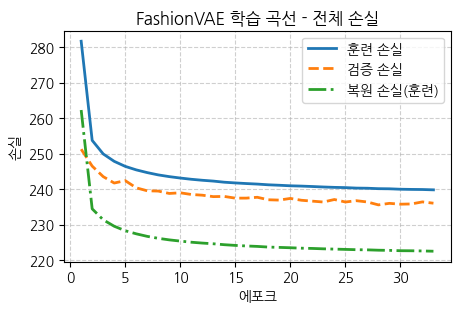

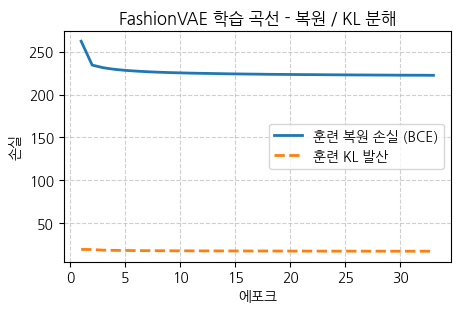

In [ ]:
# 참고 - 학습 곡선 시각화
# 전체 손실(훈련·검증) 곡선은 EpochLogger 가 보관한 이력으로 그린다.

result['log'].plot(title='FashionVAE 학습 곡선 - 전체 손실', figsize=(5, 3))

# 복원(BCE)/KL 분해는 train_loop 이 별도로 보관한 이력으로 그린다.
viz.plot_histories(
    {
        '훈련 복원 손실 (BCE)': result['train_bce'],
        '훈련 KL 발산': result['train_kl'],
    },
    title='FashionVAE 학습 곡선 - 복원 / KL 분해',
    y_label='손실',
    figsize=(5, 3)
)


## 참고 - 이미지 복원 결과 ([그림 11-3] 대응)

검증 데이터셋 앞부분의 샘플 8장을 VAE로 복원한 결과를 위(입력)/아래(복원)
한 격자로 보여 준다.


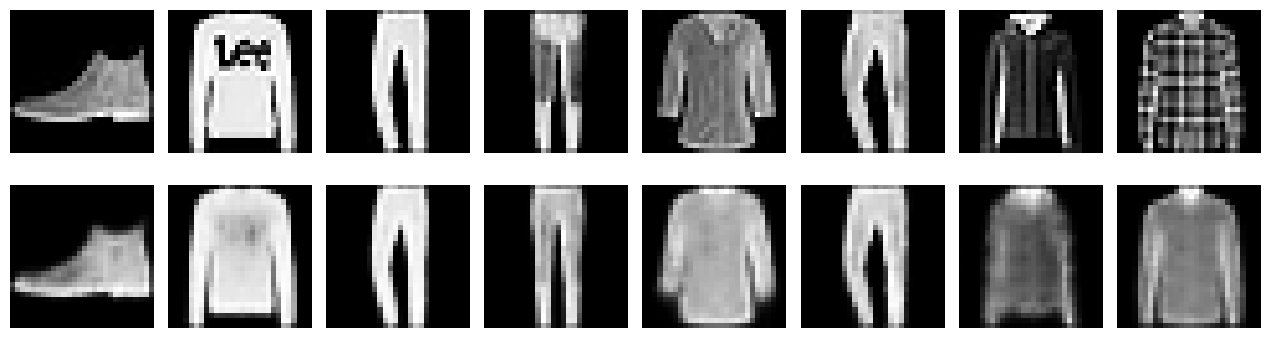

In [8]:
# 참고 - 검증 샘플 8 장의 복원 결과 시각화
model.eval()
sample_imgs, _ = next(iter(valid_loader))
sample_imgs = sample_imgs[:8].to(device)
with torch.no_grad():
    recon, _, _ = model(sample_imgs)

imgs = list(sample_imgs.cpu()) + list(recon.cpu())

#descs = ([f'입력 {i}' for i in range(8)]
#         + [f'복원 {i}' for i in range(8)])
#viz.plot_images(imgs, descs, images_per_row=8)
viz.plot_images(imgs, images_per_row=8)


## [코드 11-6] 표준 정규 분포로 샘플링해 이미지 생성 ([그림 11-4] 대응)

잠재 공간이 KL 발산 덕분에 표준 정규 분포에 가깝게 맞춰져 있으므로,
`torch.randn(16, LATENT_DIM)`으로 만든 잠재 벡터를 디코더에 입력하면
데이터셋에 포함되어 있을 법한 새로운 이미지를 만들 수 있다.


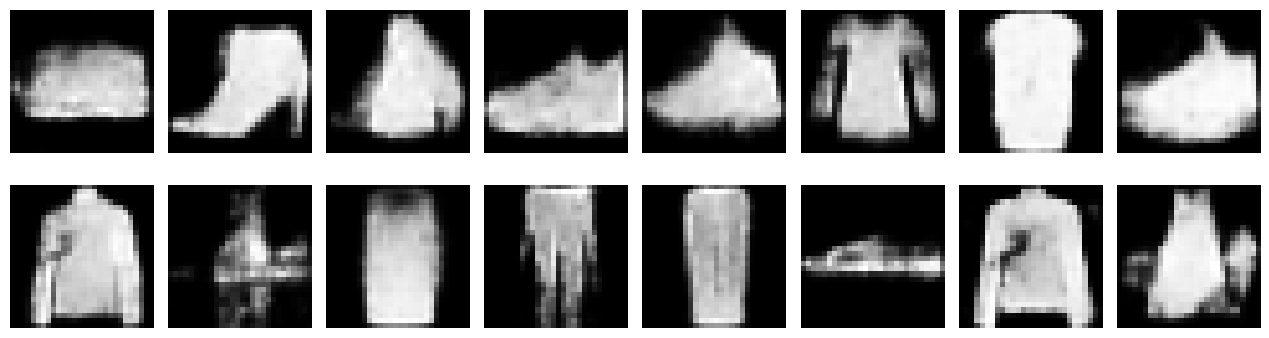

In [9]:
########################################################################################
# 코드 11-5 - 표준 정규 분포로 샘플링한 잠재 벡터로 이미지 생성
########################################################################################
model.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM).to(device)  # N(0, 1)에서 잠재 벡터 샘플링
    generated = model.decode(z).cpu()

# viz.plot_images(
#     list(generated), [f'생성 {i}' for i in range(16)], images_per_row=8,
# )
viz.plot_images(
    list(generated), images_per_row=8,
)


## [코드 11-7] 잠재 공간 보간 ([그림 11-5] 대응)

두 이미지의 잠재 벡터(중심 mu) 사이를 선형 결합해 10단계로 보간한다. KL
발산이 잠재 공간을 빈틈없이 채워 두기 때문에 중간 단계의 잠재 벡터로도
그럴듯한 이미지가 만들어진다. 본문은 앵클 부츠에서 풀오버로 이어지는
보간이지만, 여기서는 검증 샘플 중 클래스가 다른 두 이미지로 보간한다.


In [10]:
########################################################################################
# 코드 11-6 - 잠재 공간의 보간
########################################################################################

# 두 이미지의 잠재 벡터를 합이 1인 가중치로 보간해 중간 잠재 벡터 생성
def interpolate(model, img_a, img_b, steps=10, device=device):
    model.eval()
    with torch.no_grad():
        # 입력 이미지들을 인코더를 통해 잠재 벡터로 변환
        mu_a, _ = model.encode(img_a.unsqueeze(0).to(device))
        mu_b, _ = model.encode(img_b.unsqueeze(0).to(device))
        # 보간을 위한 가중치를 생성하고 가중합으로 중간 잠재 벡터를 계산
        alphas = torch.linspace(0, 1, steps).to(device)
        zs = torch.stack(
            [(1 - a) * mu_a + a * mu_b for a in alphas]
        ).squeeze(1)
        return model.decode(zs)


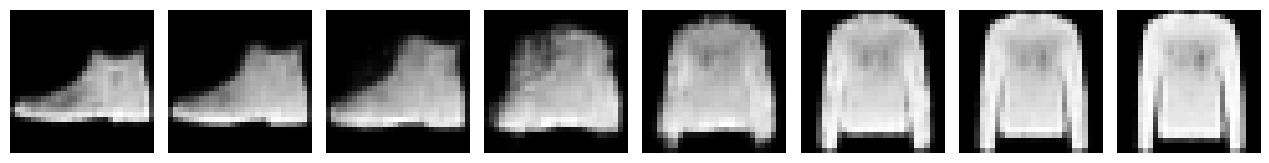

In [11]:
# 참고 - 클래스가 다른 두 검증 샘플 사이의 잠재 공간 보간 결과
first_imgs, first_labels = next(iter(valid_loader))
idx_a, idx_b = 0, 0
for i in range(1, len(first_imgs)):
    if first_labels[i].item() != first_labels[idx_a].item():
        idx_b = i
        break

interp = interpolate(
    model, first_imgs[idx_a], first_imgs[idx_b], steps=8, device=device
).to('cpu')
labels = first_labels.tolist()
# descs = (
#     [f'시작 (클래스 {labels[idx_a]})']
#     + [f'{i / 9:.2f}' for i in range(1, 9)]
#     + [f'끝 (클래스 {labels[idx_b]})']
# )
#viz.plot_images(list(interp), descs, images_per_row=10)
viz.plot_images(list(interp), images_per_row=8)


본문 [그림 11-5]와 마찬가지로 시작 이미지에서 끝 이미지로 자연스럽게
변화하는 보간 결과를 확인할 수 있다. 중간 단계의 이미지는 두 클래스 어느
쪽에도 속하지 않는 모호한 형태로, 잠재 공간이 연속적으로 채워져 있을 때만
관측할 수 있는 패턴이다.
